# Battle of the Sexes (BoS) — entrega

Notebook de la entrega: corre los experimentos en Battle of the Sexes con FP, RM y RandomAgent (implementaciones del equipo, en `agents/`). Persiste `history` dicts en `data/bos/`, guarda figuras en `images/bos/`, y registra el progreso en `logs/bos/BoS.log`.

Las gráficas usan los helpers de `utils.plots` (compartidos por todos los notebooks del equipo). Configuración: demos single-seed con `SEED=1` × 10000 iter para las pairings (FP×FP, RM×RM, FP×RM, RandomAgent×{Random, FP, RM}), y régimen multi-seed corto con `SEEDS=range(100)` × 200 iter para el scatter en el espacio de utilidades.

## Setup

In [1]:
import sys
sys.path.append('..')

%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

# Agentes del equipo
from games.bos import BoS
from agents.fictitiousplay import FictitiousPlay
from agents.regretmatching import RegretMatching
from agents.random_agent import RandomAgent

# Infraestructura compartida (utils/)
from utils.logger import get_logger
from utils.storage import cached, savefig
from utils.plots import (
    plot_policy_evolution,
    plot_distance_to_nash,
    plot_cumulative_average_reward,
    plot_cumulative_regret,
    plot_average_positive_regret,
    plot_instantaneous_vs_average_policy,
    plot_joint_action_heatmap,
)

# Helper para ejecutar y cachear corridas, y para distribuciones de joint actions
from utils import experiments as exp

log = get_logger(notebook_name='BoS')

# Constantes del experimento
ITERATIONS = 10000
SEED = 1                     # single-seed para los demos individuales
SEEDS = [1, 7, 42]           # multi-seed para el heatmap promediado
LABELS = ['Cine', 'Partido']

# Equilibrio mixto de BoS (referencia para plot_distance_to_nash).
# Cada agente juega su accion preferida con probabilidad 2/3:
#   agent_0 (prefiere Cine):   Cine=2/3, Partido=1/3
#   agent_1 (prefiere Partido): Cine=1/3, Partido=2/3
NASH_MIXED = {
    'agent_0': np.array([2/3, 1/3]),
    'agent_1': np.array([1/3, 2/3]),
}

log.info('Setup BoS listo')

# Pairings y constantes multi-seed (usados por el scatter en espacio de utilidades)
bos_pairs = {
    'FP vs FP':  [(FictitiousPlay, {}), (FictitiousPlay, {})],
    'RM vs RM':  [(RegretMatching, {}), (RegretMatching, {})],
    'FP vs RM':  [(FictitiousPlay, {}), (RegretMatching, {})],
}
SEEDS_MANY = list(range(100))
ITER_FEW = 200



2026-05-27 21:57:10 | INFO    | Setup BoS listo


In [2]:
# Payoffs de BoS indexados por (acción_agent_0, acción_agent_1) → (r0, r1)
# 0 = Cine, 1 = Partido — usado por varias celdas más abajo para reconstruir
# rewards a partir de las acciones jugadas.
BOS_PAYOFFS = np.array([
    [[2, 1], [0, 0]],   # (Cine, Cine)=(2,1); (Cine, Partido)=(0,0)
    [[0, 0], [1, 2]],   # (Partido, Cine)=(0,0); (Partido, Partido)=(1,2)
])


def reward_history_from_actions(action_history):
    """Reconstruye reward por iter de cada agente a partir de las acciones jugadas."""
    a0 = action_history['agent_0'].astype(int)
    a1 = action_history['agent_1'].astype(int)
    rewards = BOS_PAYOFFS[a0, a1]    # shape (T, 2)
    return rewards[:, 0], rewards[:, 1]

## FictitiousPlay vs FictitiousPlay

FP modela al oponente como una distribución empírica sobre acciones pasadas (`counts_other / sum(counts_other)`) y juega greedy (mejor respuesta) contra esa creencia. En BoS la dinámica converge a UNO de los dos equilibrios puros — cuál depende del seed.

In [3]:
log.info('FP vs FP en BoS — iniciando experimento')

agent_pair_fp = [(FictitiousPlay, {}), (FictitiousPlay, {})]
history_fp = exp.cached_run('bos_history_fp_vs_fp', BoS(), agent_pair_fp,
                              iterations=ITERATIONS, seed=SEED)

log.info(f'FP vs FP: política final agent_0={history_fp["policy_history"]["agent_0"][-1].round(3)}, '
         f'agent_1={history_fp["policy_history"]["agent_1"][-1].round(3)}')

2026-05-27 21:57:10 | INFO    | FP vs FP en BoS — iniciando experimento


2026-05-27 21:57:10 | INFO    | FP vs FP: política final agent_0=[1. 0.], agent_1=[1. 0.]


### Evolución de la política

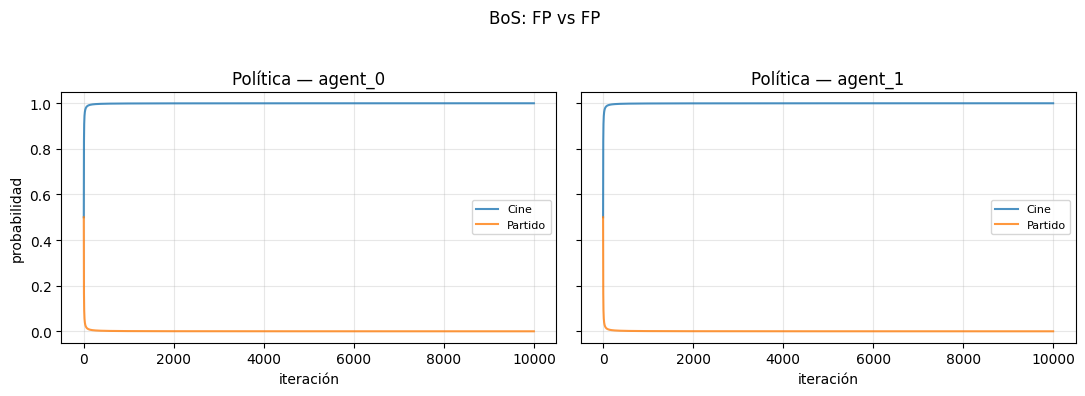

In [4]:
plot_policy_evolution(history_fp, action_labels=LABELS,
                       title='BoS: FP vs FP', save='bos/policy_evolution_fp_vs_fp')
plt.show()

### Distancia al Nash mixto

En BoS el equilibrio mixto es $((2/3, 1/3), (1/3, 2/3))$ pero esta dinámica converge a UN equilibrio puro. Por eso la distancia al mixto **no tiende a 0**: a medida que la política se concentra en uno de los puros, la distancia crece y se estabiliza en un valor positivo. La curva sigue siendo informativa porque permite ver el momento exacto en que cada agente "elige" un puro.

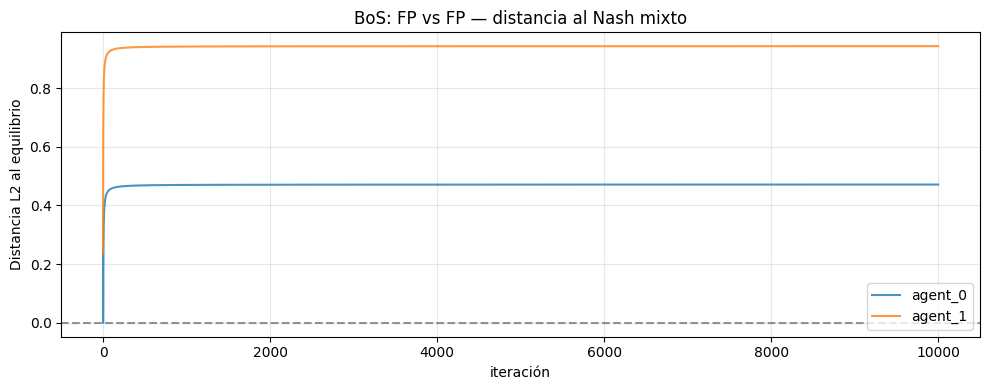

In [5]:
plot_distance_to_nash(history_fp, nash=NASH_MIXED,
                       title='BoS: FP vs FP — distancia al Nash mixto',
                       save='bos/distance_to_nash_fp_vs_fp')
plt.show()


### Reward promedio acumulado

A medida que ambos agentes convergen al mismo equilibrio puro (Cine, Cine) o (Partido, Partido), el reward promedio acumulado tiende al payoff de equilibrio: uno de los agentes hacia 2 y el otro hacia 1, según cuál puro se haya seleccionado.

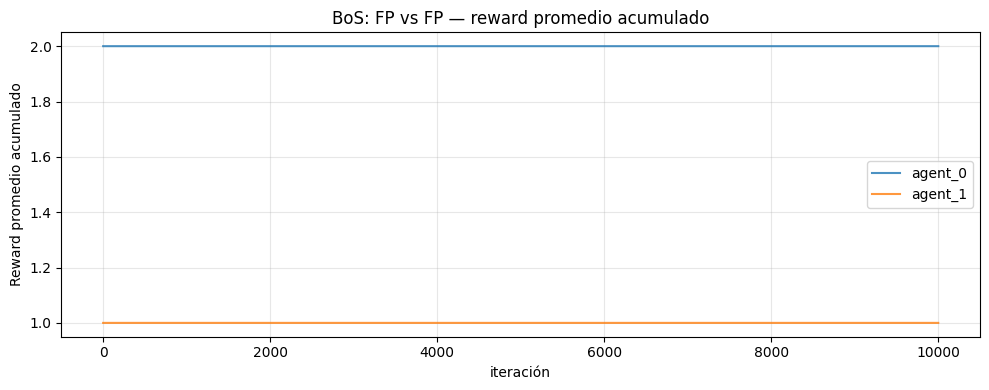

In [6]:
plot_cumulative_average_reward(history_fp, max_iter=ITERATIONS,
                                title='BoS: FP vs FP — reward promedio acumulado',
                                save='bos/reward_cum_avg_fp_vs_fp')
plt.show()


## RegretMatching vs RegretMatching

RM ajusta la política proporcionalmente a los regrets positivos acumulados (Hart & Mas-Colell, 2000). A diferencia de FP, no juega greedy sino que muestrea, por lo que la política instantánea oscila aunque el promedio se estabilice. En BoS, una sola corrida puede colapsar a un NE puro (no es CE) — el equilibrio correlacionado aparece como propiedad del **promedio sobre muchas corridas** (ver sección multi-seed).

In [7]:
log.info('RM vs RM en BoS — iniciando experimento')

agent_pair_rm = [(RegretMatching, {}), (RegretMatching, {})]
history_rm = exp.cached_run('bos_history_rm_vs_rm', BoS(), agent_pair_rm,
                              iterations=ITERATIONS, seed=SEED)

log.info(f'RM vs RM: política promedio final agent_0={history_rm["policy_history"]["agent_0"][-1].round(3)}, '
         f'agent_1={history_rm["policy_history"]["agent_1"][-1].round(3)}')

2026-05-27 21:57:10 | INFO    | RM vs RM en BoS — iniciando experimento


2026-05-27 21:57:11 | INFO    | RM vs RM: política promedio final agent_0=[1. 0.], agent_1=[0.999 0.001]


### Política promedio aprendida

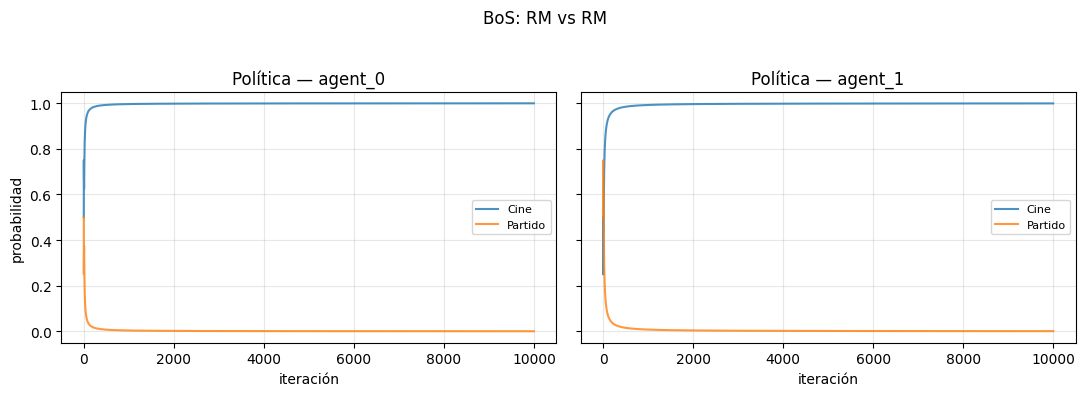

In [8]:
plot_policy_evolution(history_rm, action_labels=LABELS,
                       title='BoS: RM vs RM', save='bos/policy_evolution_rm_vs_rm')
plt.show()

### Distancia al Nash mixto

Mismo criterio que en FP×FP: la distancia al mixto $((2/3,1/3),(1/3,2/3))$ no tiende a 0 porque RM, en self-play sobre BoS, también colapsa a un equilibrio puro.

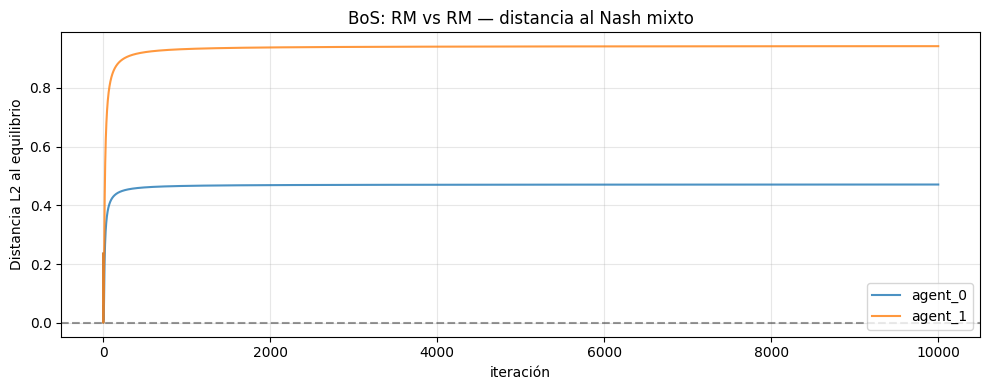

In [9]:
plot_distance_to_nash(history_rm, nash=NASH_MIXED,
                       title='BoS: RM vs RM — distancia al Nash mixto',
                       save='bos/distance_to_nash_rm_vs_rm')
plt.show()


### Reward promedio acumulado

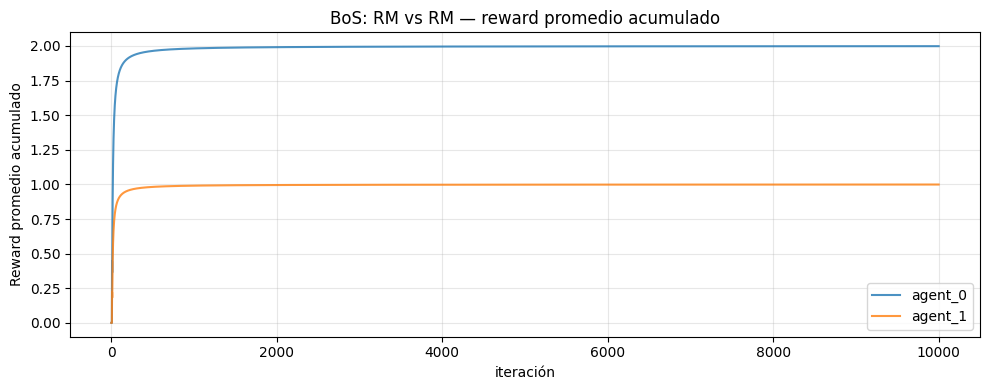

In [10]:
plot_cumulative_average_reward(history_rm, max_iter=ITERATIONS,
                                title='BoS: RM vs RM — reward promedio acumulado',
                                save='bos/reward_cum_avg_rm_vs_rm')
plt.show()


### Regrets acumulados

Oscilan entre positivos y negativos según qué acción habría sido mejor en retrospectiva. La política de RM se construye renormalizando los regrets positivos.

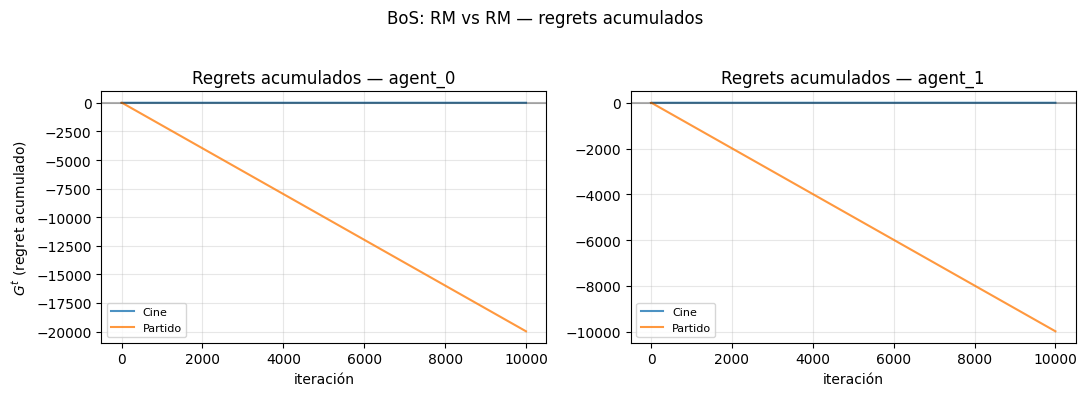

In [11]:
plot_cumulative_regret(history_rm, action_labels=LABELS,
                        title='BoS: RM vs RM — regrets acumulados',
                        save='bos/cum_regrets_rm_vs_rm')
plt.show()

### Regret promedio positivo / t

Métrica para validar la garantía no-regret de Hart & Mas-Colell: $\frac{1}{t}\overline{\max(G^t, 0)}$ debe tender a 0 cuando $t \to \infty$.

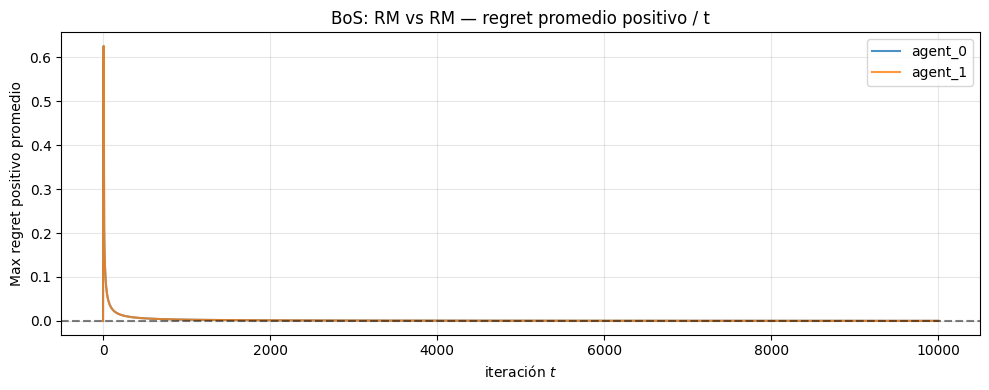

In [12]:
plot_average_positive_regret(history_rm,
                              title='BoS: RM vs RM — regret promedio positivo / t',
                              save='bos/avg_positive_regret_rm_vs_rm')
plt.show()


### Política instantánea vs promedio temporal

La instantánea (`curr_policy`) oscila; la promediada (`learned_policy`) tiende a estabilizarse. Esta es la propiedad clave de RM en juegos con múltiples equilibrios.

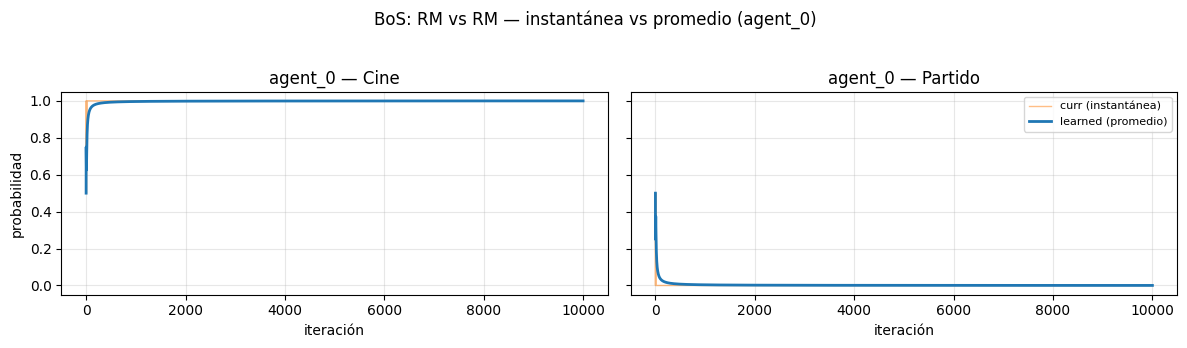

In [13]:
plot_instantaneous_vs_average_policy(history_rm, action_labels=LABELS,
                                      title='BoS: RM vs RM — instantánea vs promedio (agent_0)',
                                      save='bos/curr_vs_avg_policy_rm_vs_rm')
plt.show()

## FictitiousPlay vs RegretMatching

FP fuerza la coordinación: una vez que detecta sesgo en el oponente, juega mejor respuesta pura. RM se acomoda al patrón forzado por FP. La política aprendida de FP suele converger más rápido.

In [14]:
log.info('FP vs RM en BoS — iniciando experimento')

agent_pair_fp_rm = [(FictitiousPlay, {}), (RegretMatching, {})]
history_fp_rm = exp.cached_run('bos_history_fp_vs_rm', BoS(), agent_pair_fp_rm,
                                 iterations=ITERATIONS, seed=SEED)

log.info(f'FP vs RM: política final FP={history_fp_rm["policy_history"]["agent_0"][-1].round(3)}, '
         f'RM promedio={history_fp_rm["policy_history"]["agent_1"][-1].round(3)}')

2026-05-27 21:57:12 | INFO    | FP vs RM en BoS — iniciando experimento


2026-05-27 21:57:12 | INFO    | FP vs RM: política final FP=[1. 0.], RM promedio=[1. 0.]


### Políticas aprendidas

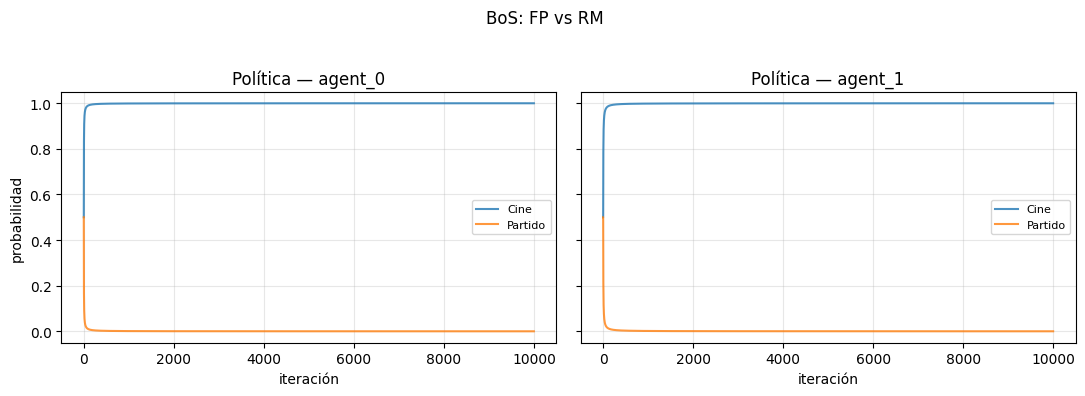

In [15]:
plot_policy_evolution(history_fp_rm, action_labels=LABELS,
                       title='BoS: FP vs RM', save='bos/policy_evolution_fp_vs_rm')
plt.show()

### Distancia al equilibrio + reward acumulado

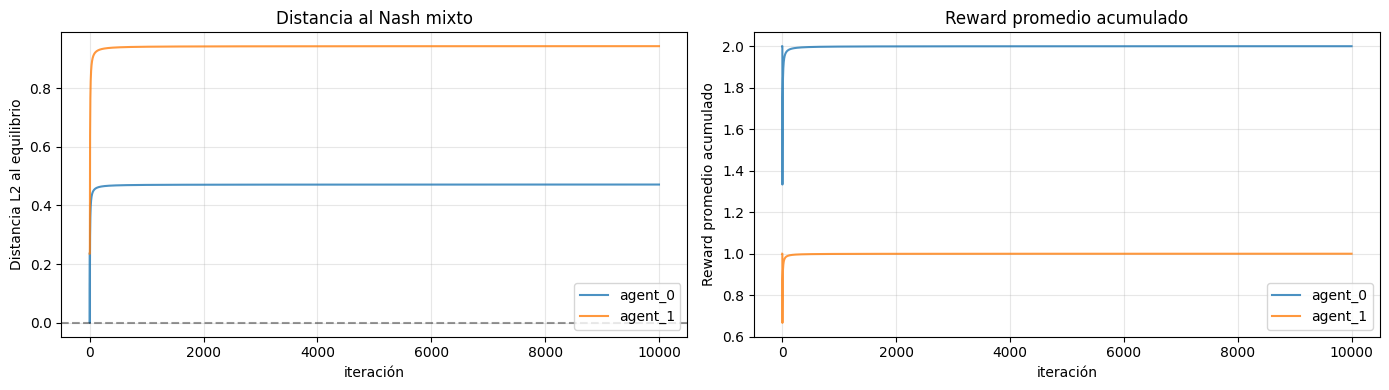

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_distance_to_nash(history_fp_rm, nash=NASH_MIXED,
                       ax=axes[0], title='Distancia al Nash mixto')
plot_cumulative_average_reward(history_fp_rm,
                                ax=axes[1], title='Reward promedio acumulado')
plt.tight_layout()
savefig('bos/distance_and_reward_fp_vs_rm')
plt.show()


### RM: política instantánea vs promedio temporal

`curr_policy` puede oscilar fuerte mientras `learned_policy` (promedio) se estabiliza.

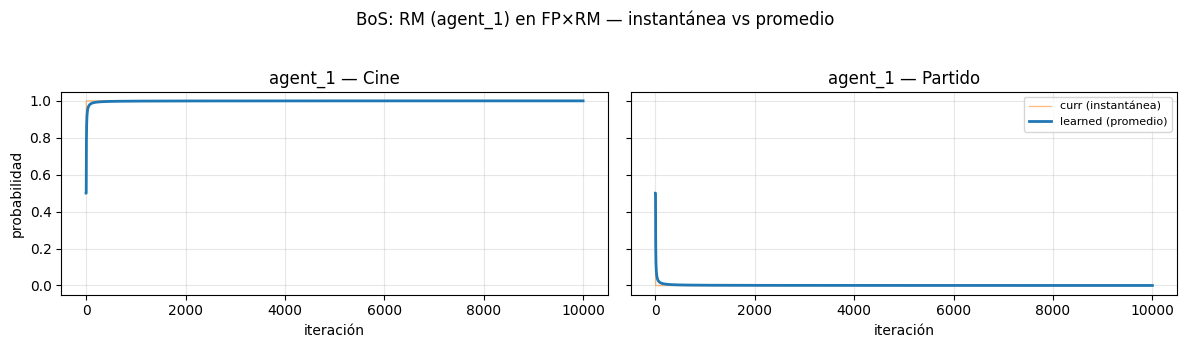

In [17]:
plot_instantaneous_vs_average_policy(history_fp_rm, action_labels=LABELS,
                                       agent='agent_1',
                                       title='BoS: RM (agent_1) en FP×RM — instantánea vs promedio',
                                       save='bos/curr_vs_avg_policy_rm_in_fp_vs_rm')
plt.show()


## RandomAgent vs RandomAgent

*Caso de control puro: ambos agentes juegan uniformemente (Cine y Partido con probabilidad 0.5 cada uno) sin aprender. Esperamos política plana en (0.5, 0.5) y reward acumulado promedio cercano a (0.75, 0.75) — el promedio sobre las cuatro celdas de la matriz: $(2{+}0{+}0{+}1)/4 = 0.75$ para ambos agentes. Sirve de baseline absoluto contra el cual comparar las pairings con aprendizaje.*

2026-05-27 21:57:13 | INFO    | Random vs Random en BoS — iniciando experimento


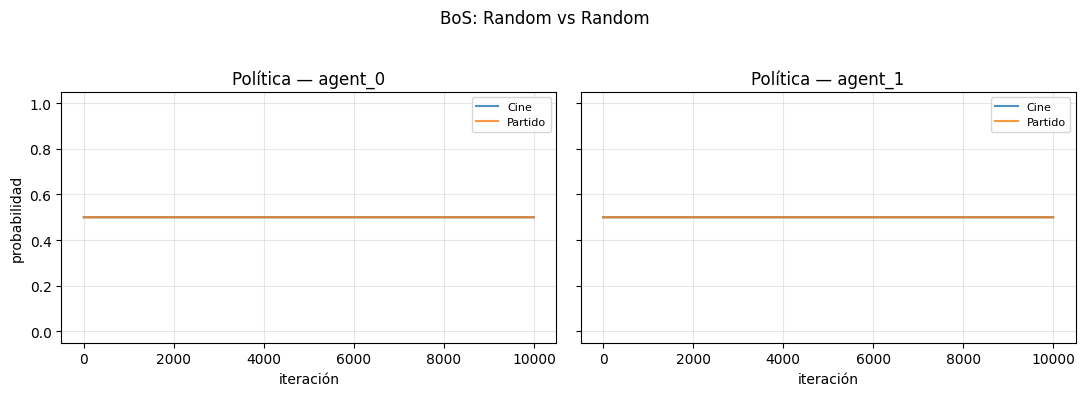

Reward acumulado promedio: agent_0=0.757, agent_1=0.755
  (esperado teórico ~0.75 para ambos)


In [18]:
log.info('Random vs Random en BoS — iniciando experimento')

agent_pair_rnd = [(RandomAgent, {}), (RandomAgent, {})]
history_rnd = exp.cached_run('bos_history_rnd_vs_rnd', BoS(), agent_pair_rnd,
                              iterations=ITERATIONS, seed=SEED)

plot_policy_evolution(history_rnd, action_labels=LABELS,
                       title='BoS: Random vs Random',
                       save='bos/policy_evolution_rnd_vs_rnd')
plt.show()

r0, r1 = reward_history_from_actions(history_rnd['action_history'])
print(f'Reward acumulado promedio: agent_0={r0.mean():.3f}, agent_1={r1.mean():.3f}')
print(f'  (esperado teórico ~0.75 para ambos)')

## FictitiousPlay vs RandomAgent

*Hipótesis: FP detecta que Random juega uniforme y calcula la mejor respuesta a esa creencia. Contra una política uniforme del oponente, la utilidad esperada de Cine para `agent_0` es $0.5 \cdot 2 + 0.5 \cdot 0 = 1.0$ y la de Partido es $0.5 \cdot 0 + 0.5 \cdot 1 = 0.5$. Cine domina, así que FP converge a Cine puro. Random sigue jugando 50/50. Reward esperado: $(1.0, 0.5)$ — FP gana, Random pierde.*

2026-05-27 21:57:13 | INFO    | FP vs Random en BoS — iniciando experimento


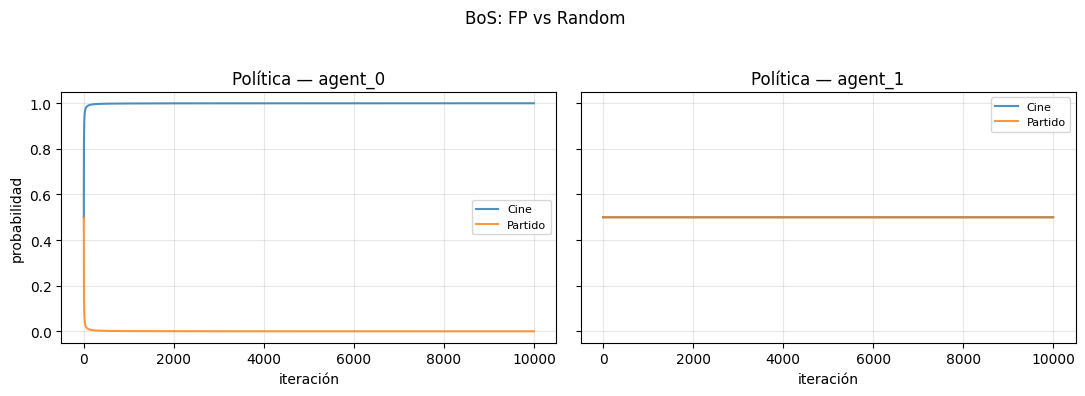

Reward acumulado promedio: FP (agent_0)=1.026, Random (agent_1)=0.513
  (esperado teórico ~1.0 para FP, ~0.5 para Random)


In [19]:
log.info('FP vs Random en BoS — iniciando experimento')

agent_pair_fp_rnd = [(FictitiousPlay, {}), (RandomAgent, {})]
history_fp_rnd = exp.cached_run('bos_history_fp_vs_rnd', BoS(), agent_pair_fp_rnd,
                                  iterations=ITERATIONS, seed=SEED)

plot_policy_evolution(history_fp_rnd, action_labels=LABELS,
                       title='BoS: FP vs Random',
                       save='bos/policy_evolution_fp_vs_rnd')
plt.show()

r0, r1 = reward_history_from_actions(history_fp_rnd['action_history'])
print(f'Reward acumulado promedio: FP (agent_0)={r0.mean():.3f}, Random (agent_1)={r1.mean():.3f}')
print(f'  (esperado teórico ~1.0 para FP, ~0.5 para Random)')

### Distancia al equilibrio + reward acumulado

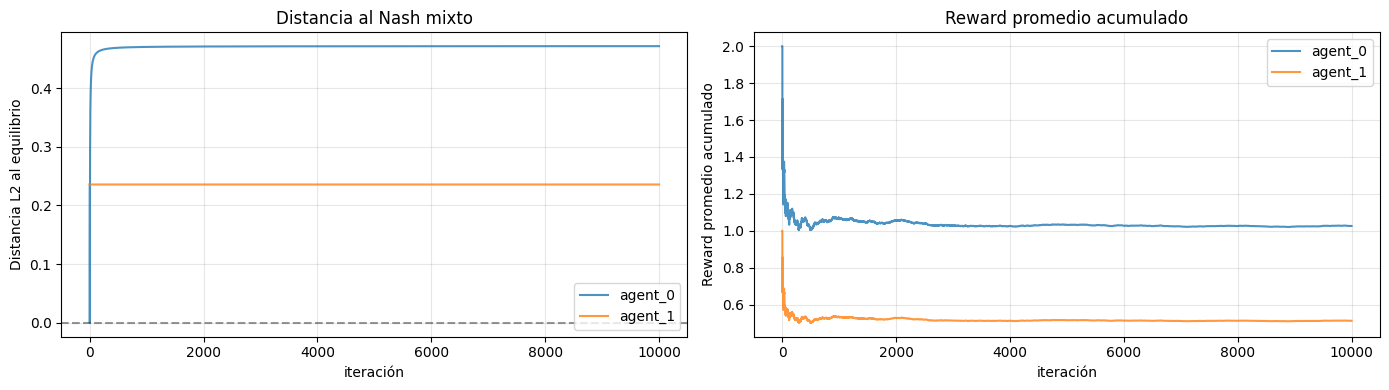

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_distance_to_nash(history_fp_rnd, nash=NASH_MIXED,
                       ax=axes[0], title='Distancia al Nash mixto')
plot_cumulative_average_reward(history_fp_rnd,
                                ax=axes[1], title='Reward promedio acumulado')
plt.tight_layout()
savefig('bos/distance_and_reward_fp_vs_rnd')
plt.show()


## RegretMatching vs RandomAgent

*Mismo razonamiento que FP vs Random: contra un oponente uniforme, Cine acumula mejor regret que Partido para `agent_0` ($+1$ esperado por iter contra $+0.5$), así que la política promedio de RM converge a Cine puro. Random sigue jugando 50/50. Reward esperado idéntico: $(1.0, 0.5)$.*

2026-05-27 21:57:14 | INFO    | RM vs Random en BoS — iniciando experimento


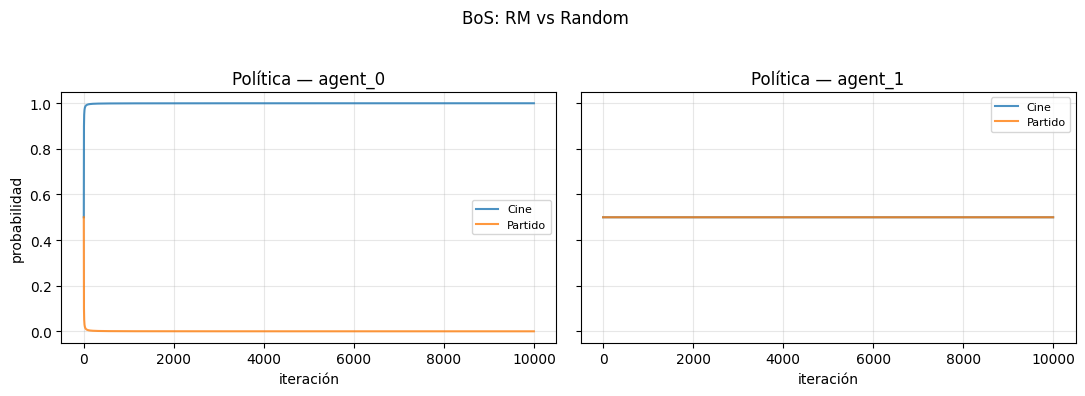

Reward acumulado promedio: RM (agent_0)=1.026, Random (agent_1)=0.513
  (esperado teórico ~1.0 para RM, ~0.5 para Random)


In [21]:
log.info('RM vs Random en BoS — iniciando experimento')

agent_pair_rm_rnd = [(RegretMatching, {}), (RandomAgent, {})]
history_rm_rnd = exp.cached_run('bos_history_rm_vs_rnd', BoS(), agent_pair_rm_rnd,
                                  iterations=ITERATIONS, seed=SEED)

plot_policy_evolution(history_rm_rnd, action_labels=LABELS,
                       title='BoS: RM vs Random',
                       save='bos/policy_evolution_rm_vs_rnd')
plt.show()

r0, r1 = reward_history_from_actions(history_rm_rnd['action_history'])
print(f'Reward acumulado promedio: RM (agent_0)={r0.mean():.3f}, Random (agent_1)={r1.mean():.3f}')
print(f'  (esperado teórico ~1.0 para RM, ~0.5 para Random)')

### Distancia al equilibrio + reward acumulado

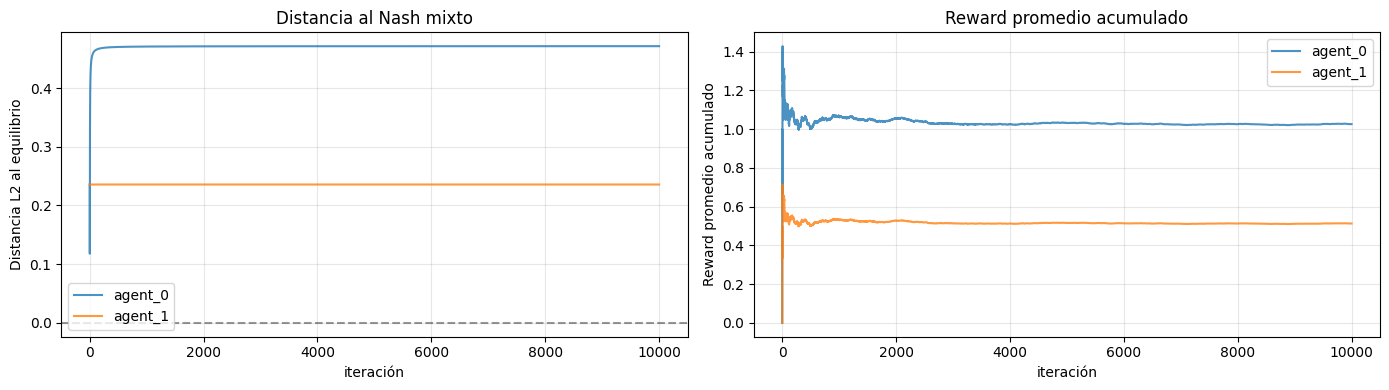

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_distance_to_nash(history_rm_rnd, nash=NASH_MIXED,
                       ax=axes[0], title='Distancia al Nash mixto')
plot_cumulative_average_reward(history_rm_rnd,
                                ax=axes[1], title='Reward promedio acumulado')
plt.tight_layout()
savefig('bos/distance_and_reward_rm_vs_rnd')
plt.show()


### Regrets acumulados

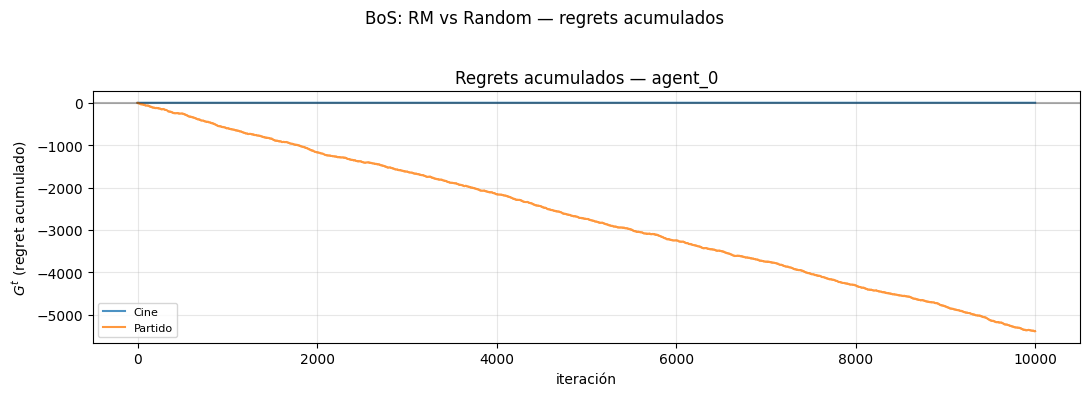

In [23]:
plot_cumulative_regret(history_rm_rnd, action_labels=LABELS,
                        title='BoS: RM vs Random — regrets acumulados',
                        save='bos/cum_regrets_rm_vs_rnd')
plt.show()


### Regret promedio positivo / t

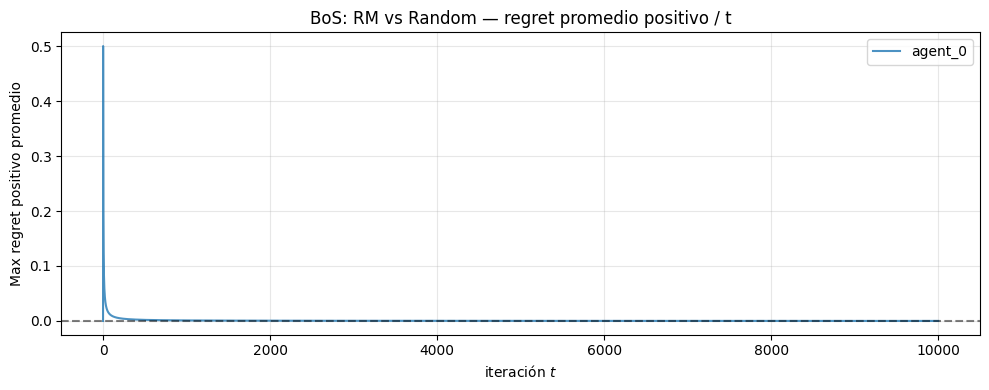

In [24]:
plot_average_positive_regret(history_rm_rnd,
                              title='BoS: RM vs Random — regret promedio positivo / t',
                              save='bos/avg_positive_regret_rm_vs_rnd')
plt.show()


### RM: política instantánea vs promedio temporal

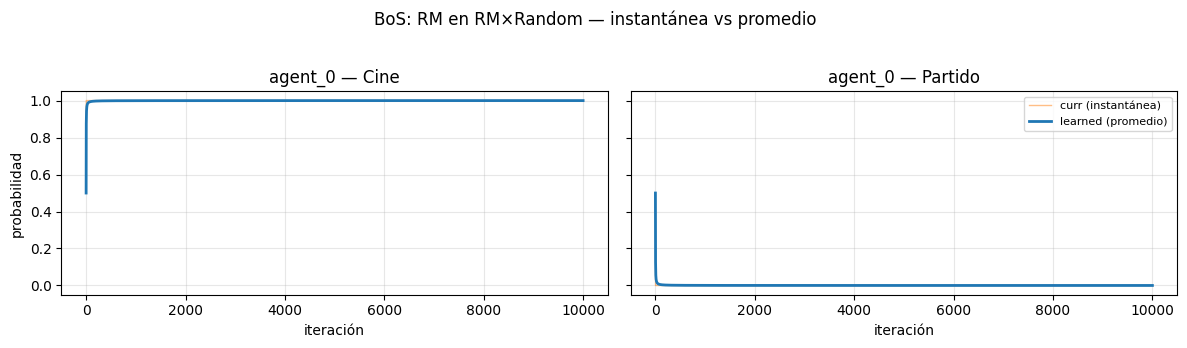

In [25]:
plot_instantaneous_vs_average_policy(history_rm_rnd, action_labels=LABELS,
                                       agent='agent_0',
                                       title='BoS: RM en RM×Random — instantánea vs promedio',
                                       save='bos/curr_vs_avg_policy_rm_in_rm_vs_rnd')
plt.show()


## Distribución empírica de acciones jugadas

La política `learned_policy` que se grafica arriba es un **promedio acumulado** (creencia empírica para FP, política promedio para RM). Pero una política promedio cercana a (0.5, 0.5) puede esconder dos historias muy distintas:

- ráfagas alternadas (100 iter de Cine, 100 de Partido, ...),
- mezcla "honesta" iter a iter (uno Cine, otro Partido, ...).

Para distinguir esto graficamos la **frecuencia empírica de Cine en una ventana móvil de 50 iteraciones**, separando por agente y por pairing. Si la curva oscila → el agente está mezclando; si se va rápido a 0 o 1 → colapso a una acción pura.

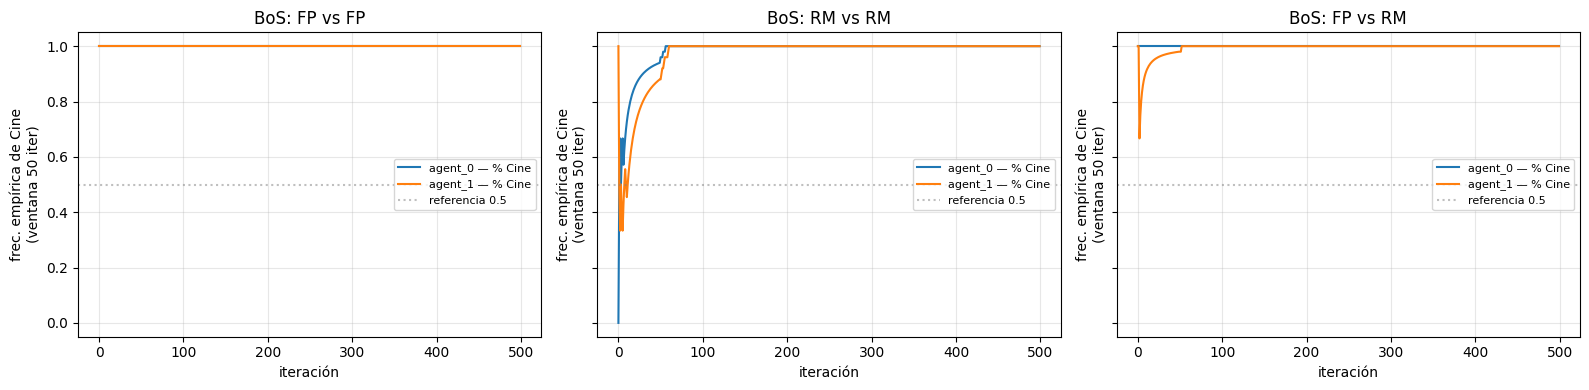

In [26]:
WINDOW = 50
HORIZON = 500    # cap visual; el colapso ocurre típicamente antes del iter 200


def rolling_action_freq(actions, n_actions, window):
    """Frecuencia de cada acción en ventana móvil [t-window+1, t]."""
    T = len(actions)
    cum = np.zeros((T + 1, n_actions))
    for a in range(n_actions):
        cum[1:, a] = np.cumsum(actions == a)
    freq = np.zeros((T, n_actions))
    for t in range(T):
        start = max(0, t - window + 1)
        freq[t] = (cum[t + 1] - cum[start]) / (t - start + 1)
    return freq


pairings_single = {
    'FP vs FP':  history_fp,
    'RM vs RM':  history_rm,
    'FP vs RM':  history_fp_rm,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (name, hist) in zip(axes, pairings_single.items()):
    for agent_id, color in zip(['agent_0', 'agent_1'], ['tab:blue', 'tab:orange']):
        actions = hist['action_history'][agent_id][:HORIZON]
        freq = rolling_action_freq(actions, n_actions=2, window=WINDOW)
        # acción 0 = Cine
        ax.plot(freq[:, 0], label=f'{agent_id} — % Cine', color=color, linewidth=1.5)
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='referencia 0.5')
    ax.set_title(f'BoS: {name}')
    ax.set_xlabel('iteración')
    ax.set_ylabel(f'frec. empírica de Cine\n(ventana {WINDOW} iter)')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(loc='center right', fontsize=8)
plt.tight_layout()
savefig('bos/empirical_action_freq_single_seed')
plt.show()

**Lectura esperada**: si FP y RM se diferencian en *cómo* convergen (FP más abrupto, RM con más oscilación inicial) eso aparece acá pero no en los plots de `learned_policy`. Si ambas curvas saltan a 1.0 o 0.0 en pocas iteraciones, confirma que en BoS la fase "exploratoria" es muy corta — la coordinación se cierra rápido en cualquier algoritmo.

## Visualización en el espacio de utilidades

Reproducimos el diagrama clásico de BoS en el espacio de utilidades (eje X = utilidad de `agent_0`, eje Y = utilidad de `agent_1`) y le superponemos los resultados de nuestros experimentos. Los puntos teóricos:

- **(2, 1)** y **(1, 2)**: los dos NE puros.
- **(2/3, 2/3)**: el NE mixto, Pareto-dominado.
- **Segmento entre (2, 1) y (1, 2)**: el conjunto de equilibrios correlacionados alcanzables como mezcla convexa de los dos NE puros.
- **(1.5, 1.5)**: el CE "fair" (mezcla 50/50), Pareto-superior al NE mixto.

Dos visualizaciones:

- **A — Trayectoria single-seed**: para cada pairing, la utilidad acumulada promedio (de iter 1 hasta iter 10000) traza una curva en el espacio. Permite ver cómo se mueve el sistema antes de colapsar.
- **B — Scatter multi-seed**: 100 corridas del régimen pre-colapso (200 iter), un punto por seed = utilidad promedio final. Muestra dónde se acumula la masa de outcomes.

In [27]:
# Equilibrios y segmento de CEs en formato del helper plot_utility_space
BOS_EQUILIBRIA = [
    {'pos': (2, 1),     'label': 'Eq-Nash puros', 'coord_text': '(2, 1)',     'color': 'black', 's': 120,
     'text_offset': (-30, 8)},
    {'pos': (1, 2),     'coord_text': '(1, 2)',                          'color': 'black', 's': 120,
     'text_offset': (8, -4)},
    {'pos': (2/3, 2/3), 'label': 'Eq-Nash mixto',  'coord_text': '(2/3, 2/3)', 'color': 'red',
     'marker': 's',    's': 100, 'text_offset': (8, -4)},
    {'pos': (1.5, 1.5), 'label': 'Eq-Correlacionado igualitario',   'coord_text': '(1.5, 1.5)', 'color': 'green',
     'marker': 'D',    's': 100, 'text_offset': (8, 8)},
]
BOS_SEGMENTS = [
    {'start': (2, 1), 'end': (1, 2), 'label': 'segmento Eq-Correlacionado'},
]

### A — Trayectoria de utilidad acumulada (single-seed)

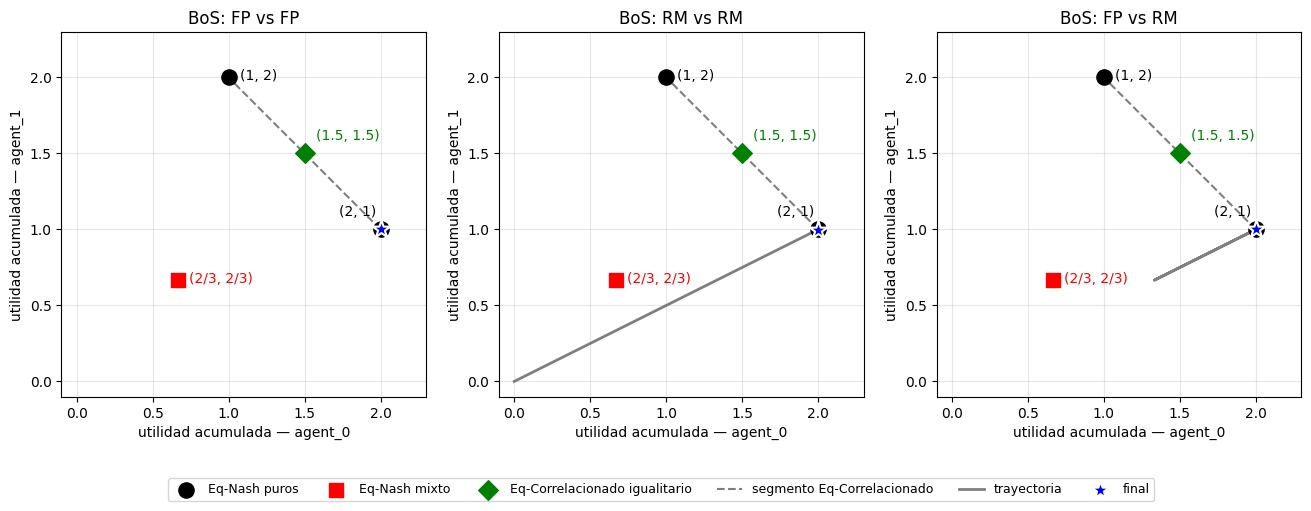

In [28]:
from utils.plots import plot_utility_space

pairings_single = {
    'FP vs FP':  history_fp,
    'RM vs RM':  history_rm,
    'FP vs RM':  history_fp_rm,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, hist) in zip(axes, pairings_single.items()):
    r0, r1 = reward_history_from_actions(hist['action_history'])
    # Promedio acumulado iter-a-iter (mismo cálculo que hace plot_utility_space).
    r0_cum = np.cumsum(r0) / np.arange(1, len(r0) + 1)
    r1_cum = np.cumsum(r1) / np.arange(1, len(r1) + 1)
    # Dibujamos primero los equilibrios/segmentos sin trayectoria.
    plot_utility_space(
        equilibria=BOS_EQUILIBRIA,
        segments=BOS_SEGMENTS,
        annotate_equilibria=True,
        ax=ax,
        title=f'BoS: {name}',
        xlim=(-0.1, 2.3),
        ylim=(-0.1, 2.3),
        xlabel='utilidad acumulada — agent_0',
        ylabel='utilidad acumulada — agent_1',
        show_legend=False,
    )
    # Trayectoria como línea sólida + estrella en el outcome final.
    ax.plot(r0_cum, r1_cum, color='dimgray', alpha=0.85, linewidth=2,
            label='trayectoria', zorder=3)
    ax.scatter(r0_cum[-1], r1_cum[-1], marker='*', s=180, color='blue',
               edgecolor='white', linewidth=1.5, zorder=6, label='final')

# Leyenda única abajo de la figura.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.02),
           ncol=len(labels), fontsize=9, frameon=True)

savefig('bos/utility_space_trajectory')
plt.show()


### B — Scatter multi-seed en el espacio de utilidades (100 seeds × 200 iter)

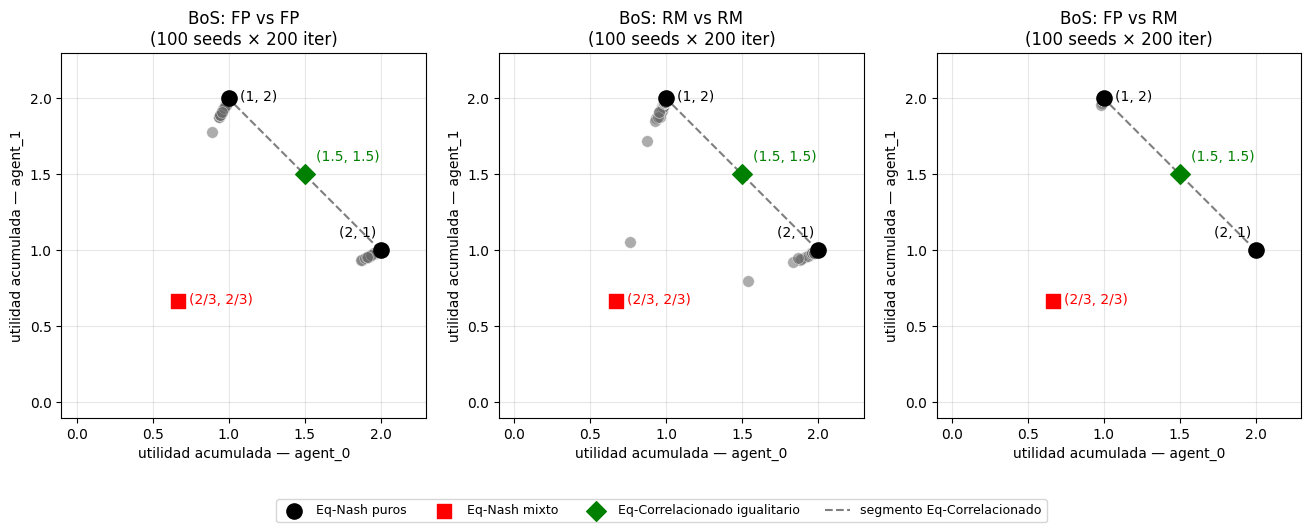


Utilidad promedio sobre seeds:
  FP vs FP: (1.472, 1.472)
  RM vs RM: (1.334, 1.583)
  FP vs RM: (1.781, 1.203)


In [29]:
def run_utility_scatter():
    """Para cada pairing, corre SEEDS_MANY × ITER_FEW y guarda la utilidad
    promedio final de cada seed (un punto en el espacio de utilidades)."""
    results = {name: [] for name in bos_pairs}
    for name, pair in bos_pairs.items():
        for seed in SEEDS_MANY:
            g = BoS(); g.reset()
            agents = {}
            for idx, agent_name in enumerate(g.agents):
                AgentClass, kw = pair[idx]
                kw = dict(kw); kw['seed'] = seed + idx
                agents[agent_name] = AgentClass(game=g, agent=agent_name, **kw)
            result = exp.play_oneshot(g, agents, ITER_FEW)
            r0, r1 = reward_history_from_actions(result['action_history'])
            results[name].append((float(r0.mean()), float(r1.mean())))
        log.info(f'{name}: utility scatter listo ({len(SEEDS_MANY)} seeds × {ITER_FEW} iter)')
    return {k: np.array(v) for k, v in results.items()}


bos_utility_scatter = cached('bos_utility_scatter', run_utility_scatter)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, pts) in zip(axes, bos_utility_scatter.items()):
    plot_utility_space(
        equilibria=BOS_EQUILIBRIA,
        segments=BOS_SEGMENTS,
        scatter=pts,
        scatter_color='dimgray',
        annotate_equilibria=True,
        ax=ax,
        title=f'BoS: {name}\n({len(pts)} seeds × {ITER_FEW} iter)',
        xlim=(-0.1, 2.3),
        ylim=(-0.1, 2.3),
        xlabel='utilidad acumulada — agent_0',
        ylabel='utilidad acumulada — agent_1',
        show_legend=False,
    )

# Leyenda única abajo solo con equilibrios/segmento (los puntos del scatter no
# necesitan entrada — el título del panel ya identifica el pairing).
handles_all, labels_all = [], []
seen = set()
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for hi, li in zip(h, l):
        if li not in seen:
            handles_all.append(hi)
            labels_all.append(li)
            seen.add(li)
fig.legend(handles_all, labels_all, loc='upper center', bbox_to_anchor=(0.5, -0.02),
           ncol=len(labels_all), fontsize=9, frameon=True)

savefig('bos/utility_space_scatter')
plt.show()

print('\nUtilidad promedio sobre seeds:')
for name, pts in bos_utility_scatter.items():
    mean_r0 = float(pts[:, 0].mean())
    mean_r1 = float(pts[:, 1].mean())
    print(f'  {name}: ({mean_r0:.3f}, {mean_r1:.3f})')


**Lectura esperada de los plots:**

- En **A**, las trayectorias deberían arrancar cerca del centro del cuadrado y migrar hacia uno de los dos vértices ((2,1) o (1,2)). FP es directo; RM tiene un transient más largo pero termina en el mismo lugar.
- En **B**, los 100 puntos por pairing **se acumulan en los extremos del segmento** (alrededor de (2,1) y (1,2)), confirmando visualmente que ningún algoritmo "encuentra" el centro del segmento (CE fair en (1.5, 1.5)). El NE mixto (2/3, 2/3) queda completamente desierto — ningún algoritmo se le acerca.

---

**Notas**:

- Los `history` dicts quedan persistidos en `data/bos/bos_history_*.pkl`. Por defecto `exp.cached_run` viene con `force=True` y re-ejecuta cada vez; pasar `force=False` para reutilizar el cache si la corrida es costosa.
- Las figuras se guardan en `images/bos/` y son referenciadas desde `docs/informe/informe.md`.
- Configuración usada: `ITERATIONS=10000` (single-seed), `SEEDS=range(100)` × `ITER_FEW=200` (multi-seed corto). Las políticas convergen típicamente en menos de 100 iteraciones, así que las 10000 dejan amplio margen de meseta; los 100 seeds dan buena resolución estadística para los scatters.